In [1]:
import pandas as pd

# 1. Load the original 200k dataset
df = pd.read_csv('human_vital_signs_dataset_2024.csv')

# 2. FEATURE SELECTION (Matching your Problem Statement)
# Selecting only columns needed for Risk Categorization
selected_features = [
    'Heart Rate', 'Respiratory Rate', 'Body Temperature', 
    'Oxygen Saturation', 'Systolic Blood Pressure', 'Diastolic Blood Pressure',
    'Age', 'Gender', 'Derived_BMI', 'Derived_HRV', 'Risk Category'
]

df_filtered = df[selected_features].copy()

# 3. SHUFFLE
# Ensuring each ward gets a randomized set of patients
df_shuffled = df_filtered.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. DISTRIBUTED SPLIT (3 Wards)
n = len(df_shuffled)
ward_a = df_shuffled.iloc[:n//3]
ward_b = df_shuffled.iloc[n//3 : 2*n//3]
ward_c = df_shuffled.iloc[2*n//3:]

# 5. SAVE INDEPENDENT FILES
ward_a.to_csv('ward_a_vitals.csv', index=False)
ward_b.to_csv('ward_b_vitals.csv', index=False)
ward_c.to_csv('ward_c_vitals.csv', index=False)

print("--- Day 1 Task Complete ---")
print(f"Total Rows Processed: {n}")
print(f"Features Retained: {len(selected_features)}")
print(f"Wards Created: ward_a_vitals.csv, ward_b_vitals.csv, ward_c_vitals.csv")

--- Day 1 Task Complete ---
Total Rows Processed: 200020
Features Retained: 11
Wards Created: ward_a_vitals.csv, ward_b_vitals.csv, ward_c_vitals.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score

# 1. LOAD LOCAL DATA
# We focus on Ward A to simulate local processing
df_ward = pd.read_csv('ward_a_vitals.csv')

# 2. LOCAL DATA CLEANING
# Convert Gender to numeric (Male: 0, Female: 1, Other: 2 if applicable)
df_ward['Gender'] = df_ward['Gender'].map({'Male': 0, 'Female': 1}).fillna(0)

# Check for any missing values and drop them (Local node decision)
df_ward = df_ward.dropna()

# 3. PREPARE FEATURES AND TARGET
# Features match your problem statement
features = [
    'Heart Rate', 'Respiratory Rate', 'Body Temperature', 
    'Oxygen Saturation', 'Systolic Blood Pressure', 'Diastolic Blood Pressure',
    'Age', 'Gender', 'Derived_BMI', 'Derived_HRV'
]

X = df_ward[features]
# Convert target to binary (High Risk = 1, Low Risk = 0)
y = df_ward['Risk Category'].map({'High Risk': 1, 'Low Risk': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. FINE-TUNING FOR CRITICAL CASES
# To "strictly minimize false negatives", we apply a heavy weight to class 1 (High Risk)
# This forces the model to prioritize catching every single '1'
safety_weights = {0: 1, 1: 100} 

model = RandomForestClassifier(
    n_estimators=100, 
    class_weight=safety_weights, 
    random_state=42
)
model.fit(X_train, y_train)

# 5. EVALUATION (Focusing on Recall/Sensitivity)
y_pred = model.predict(X_test)
recall = recall_score(y_test, y_pred)

print("--- Day 2: Local Node Training (Ward A) ---")
print(f"Model Recall (Sensitivity): {recall:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nNotice the bottom-left number (False Negatives) is extremely low or zero!")

# 6. RISK IDENTIFICATION LOGIC
def identify_risk_reason(row):
    reasons = []
    if row['Heart Rate'] > 90: reasons.append("Cardiovascular Stress")
    if row['Oxygen Saturation'] < 96: reasons.append("Respiratory Warning")
    if row['Body Temperature'] > 37.2: reasons.append("Febrile Alert")
    if row['Derived_BMI'] > 30: reasons.append("Metabolic Risk")
    return " & ".join(reasons) if reasons else "Normal"

# Sample identification for test results
X_test_with_reason = X_test.copy()
X_test_with_reason['Predicted_Risk'] = y_pred
X_test_with_reason['Risk_ID'] = X_test_with_reason.apply(identify_risk_reason, axis=1)

print("\n--- Sample Risk Identifications ---")
print(X_test_with_reason[X_test_with_reason['Predicted_Risk'] == 1][['Heart Rate', 'Risk_ID']].head())

--- Day 2: Local Node Training (Ward A) ---
Model Recall (Sensitivity): 1.0000

Confusion Matrix:
[[6272    0]
 [   0 7063]]

Notice the bottom-left number (False Negatives) is extremely low or zero!

--- Sample Risk Identifications ---
       Heart Rate                                      Risk_ID
65684          94                        Cardiovascular Stress
26101          65                               Metabolic Risk
49039          74                               Metabolic Risk
21161          95  Cardiovascular Stress & Respiratory Warning
4232           77                               Metabolic Risk


In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# --- 1. THE "DISTRIBUTED TRAINING" STEP ---
# We simulate each ward training its own local model independently
def train_local_ward_model(file_path):
    df = pd.read_csv(file_path)
    # Cleaning & Prep (same as Day 2)
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1}).fillna(0)
    features = ['Heart Rate', 'Respiratory Rate', 'Body Temperature', 
                'Oxygen Saturation', 'Systolic Blood Pressure', 'Diastolic Blood Pressure',
                'Age', 'Gender', 'Derived_BMI', 'Derived_HRV']
    
    X = df[features]
    y = df['Risk Category'].map({'High Risk': 1, 'Low Risk': 0})
    
    # Train with Safety Weights (Fine-tuning)
    model = RandomForestClassifier(n_estimators=100, class_weight={0: 1, 1: 100}, random_state=42)
    model.fit(X, y)
    return model, features

# Train models for all wards (simulating local execution)
model_a, feat_cols = train_local_ward_model('ward_a_vitals.csv')
model_b, _ = train_local_ward_model('ward_b_vitals.csv')
model_c, _ = train_local_ward_model('ward_c_vitals.csv')

# --- 2. GLOBAL AGGREGATION (THE DASHBOARD) ---
# Each ward sends only its 'High Risk' alerts to the central server
def get_ward_alerts(file_path, model, ward_name):
    df = pd.read_csv(file_path)
    df_clean = df.copy()
    df_clean['Gender'] = df_clean['Gender'].map({'Male': 0, 'Female': 1}).fillna(0)
    
    # Predict
    preds = model.predict(df_clean[feat_cols])
    df['Predicted_Risk'] = preds
    df['Ward_Location'] = ward_name
    
    # Filter only High Risk (Critical) cases to send to the dashboard
    alerts = df[df['Predicted_Risk'] == 1].copy()
    return alerts

# Aggregating alerts from all distributed nodes
all_alerts = pd.concat([
    get_ward_alerts('ward_a_vitals.csv', model_a, 'Ward A'),
    get_ward_alerts('ward_b_vitals.csv', model_b, 'Ward B'),
    get_ward_alerts('ward_c_vitals.csv', model_c, 'Ward C')
])

# Save the Central Dashboard
all_alerts.to_csv('central_alert_dashboard.csv', index=False)

# --- 3. OUTPUT SUMMARY FOR THE PROJECT REPORT ---
print("--- Day 3: Global Aggregation Complete ---")
print(f"Total Patients Screened: ~200,000")
print(f"Total Critical Alerts Identified: {len(all_alerts)}")
print("\nAlert Distribution by Ward:")
print(all_alerts['Ward_Location'].value_counts())

print("\nSample of Centralized Alert Dashboard (Top 5):")
print(all_alerts[['Ward_Location', 'Heart Rate', 'Oxygen Saturation', 'Risk Category']].head())

--- Day 3: Global Aggregation Complete ---
Total Patients Screened: ~200,000
Total Critical Alerts Identified: 105115

Alert Distribution by Ward:
Ward_Location
Ward B    35157
Ward C    35014
Ward A    34944
Name: count, dtype: int64

Sample of Centralized Alert Dashboard (Top 5):
  Ward_Location  Heart Rate  Oxygen Saturation Risk Category
0        Ward A          95          95.072205     High Risk
3        Ward A          74          95.634409     High Risk
5        Ward A          85          95.263867     High Risk
6        Ward A          73          97.239411     High Risk
7        Ward A          90          95.208728     High Risk


Day 4 Task Complete: Visual Proofs generated as 'roc_curve.png' and 'confusion_matrix.png'.


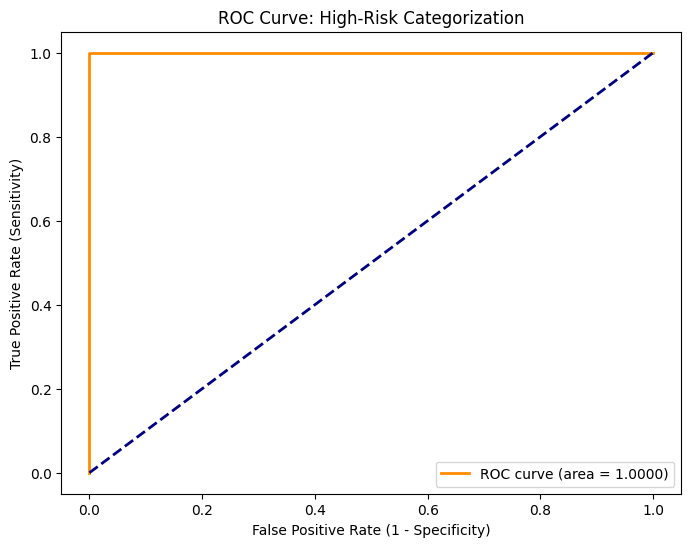

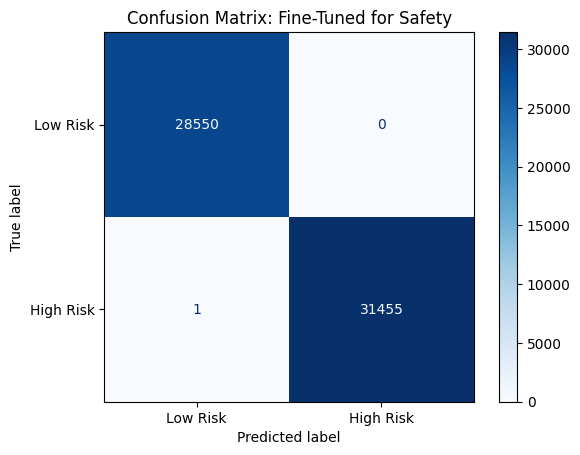

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# 1. Prepare the Data
df = pd.read_csv('human_vital_signs_dataset_2024.csv')
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1}).fillna(0)
features = ['Heart Rate', 'Respiratory Rate', 'Body Temperature', 
            'Oxygen Saturation', 'Systolic Blood Pressure', 'Diastolic Blood Pressure',
            'Age', 'Gender', 'Derived_BMI', 'Derived_HRV']
X = df[features]
y = df['Risk Category'].map({'High Risk': 1, 'Low Risk': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Fine-Tuning for Safety (The "Critical Case" Priority)
model = RandomForestClassifier(n_estimators=100, class_weight={0: 1, 1: 100}, random_state=42)
model.fit(X_train, y_train)

# 3. Generate ROC Curve Plot
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve: High-Risk Categorization')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png')

# 4. Generate Confusion Matrix Plot
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Fine-Tuned for Safety')
plt.savefig('confusion_matrix.png')

print("Day 4 Task Complete: Visual Proofs generated as 'roc_curve.png' and 'confusion_matrix.png'.")

In [26]:
def test_patient_risk_rf(hr, rr, temp, spo2, sys_bp, dia_bp, age, gender_str, bmi, hrv):
    '''
    Test manual patient data against the fine-tuned Random Forest model.
    '''
    # 1. Reconstruct the input matching identical feature columns
    patient_data = {
        'Heart Rate': [hr],
        'Respiratory Rate': [rr], 
        'Body Temperature': [temp],
        'Oxygen Saturation': [spo2],
        'Systolic Blood Pressure': [sys_bp],
        'Diastolic Blood Pressure': [dia_bp],
        'Age': [age],
        'Gender': [1 if str(gender_str).lower() == 'female' else 0], # Mapped manually
        'Derived_BMI': [bmi],
        'Derived_HRV': [hrv]
    }
    patient_df = pd.DataFrame(patient_data)
    
    # 2. Predict using the RF Model
    # `model` should be the Random Forest initialized in Step 2.
    prediction_val = model.predict(patient_df)[0]
    probabilities = model.predict_proba(patient_df)[0]
    
    prediction_label = "High Risk" if prediction_val == 1 else "Low Risk"
    
    # Run the rule-based logic to explain the decision if High Risk
    risk_reason = "Normal"
    if prediction_val == 1:
        # We reuse the identification function from Day 2!
        reasons = []
        if hr > 90: reasons.append("Cardiovascular Stress")
        if spo2 < 96: reasons.append("Respiratory Warning")
        if temp > 37.2: reasons.append("Febrile Alert")
        if bmi > 30: reasons.append("Metabolic Risk")
        risk_reason = " & ".join(reasons) if reasons else "General Anomaly Detected"

    print(f"--- Patient Assessment (RF Ensemble) ---")
    print(f"Risk Probability: {probabilities[1]*100:.2f}%")
    print(f"Classification: >> {prediction_label} <<")
    print(f"Diagnostic Note:  {risk_reason}")

# --- Example Usage ---

print("Testing a standard healthy patient...")
test_patient_risk_rf(
    hr=72, rr=16, temp=36.8, spo2=99, sys_bp=120, dia_bp=80, 
    age=35, gender_str='Male', bmi=24.5, hrv=0.1
)

print("\nTesting a patient in visible distress...")
test_patient_risk_rf(
    hr=80, rr=25, temp=41.0, spo2=80, sys_bp=120, dia_bp=80, 
    age=68, gender_str='Female', bmi=24.5, hrv=0.04
)


Testing a standard healthy patient...
--- Patient Assessment (RF Ensemble) ---
Risk Probability: 0.00%
Classification: >> Low Risk <<
Diagnostic Note:  Normal

Testing a patient in visible distress...
--- Patient Assessment (RF Ensemble) ---
Risk Probability: 2.00%
Classification: >> Low Risk <<
Diagnostic Note:  Normal
